## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [16]:
#Install libraries needed
%pip install seaborn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [47]:
#Part 1: Libraries
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
#Part 2: Data Collection and Loading 
#1.TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Load dataset and convert to DataFrame:
housing = fetch_california_housing()

CalHouse = pd.DataFrame(housing.data, columns=housing.feature_names)
CalHouse['MedHouseVal'] = housing.target   # the target: median house value

print(CalHouse.head())
print(CalHouse.shape)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


In [10]:
#Part 3: Quick Check of Data
#1. TODO: Display the first few rows of the dataset to understand its structure.
# Add your code here:
print(CalHouse.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [11]:
#Part 3: Quick Check of Data
#2. TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.
# Add your code here:
print(CalHouse.info())
print(CalHouse.describe)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
<bound method NDFrame.describe of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.0730

In [12]:
#Part 4: EDA and Data Preprocessing 
#1.TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.
# Add your code here:

print(CalHouse.isnull().sum())
print(CalHouse.isnull())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0       False     False     False      False       False     False     False   
1       False     False     False      False       False     False     False   
2       False     False     False      False       False     False     False   
3       False     False     False      False       False     False     False   
4       False     False     False      False       False     False     False   
...       ...       ...       ...        ...         ...       ...       ...   
20635   False     False     False      False       False     False     False   
20636   False     False     False      False       False     False     False   
20637   False     False     False      False       False     False     False   
20638   False     False     False 

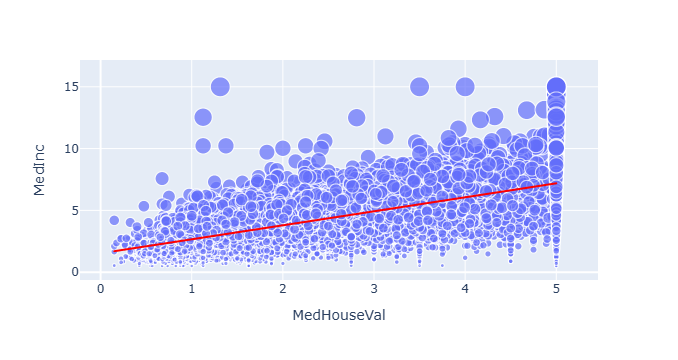

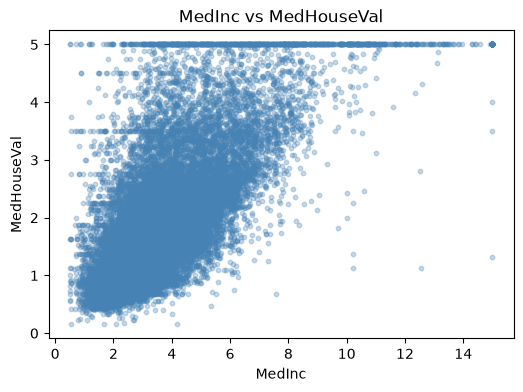

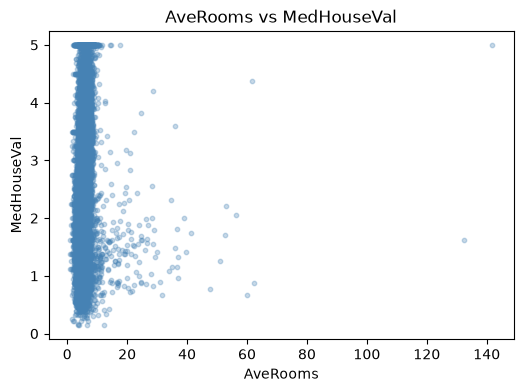

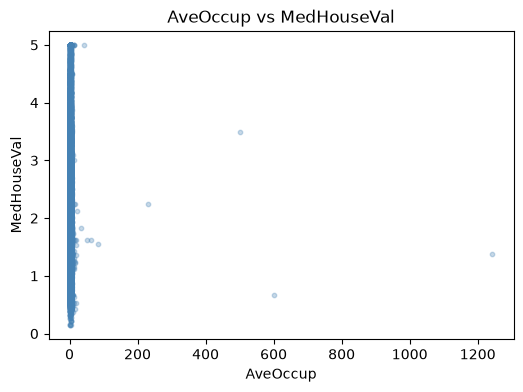

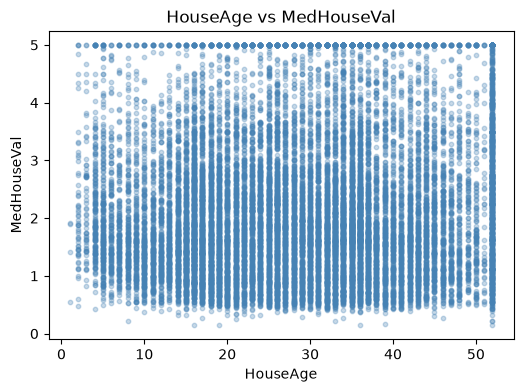

In [40]:
#Part 4: EDA and Data Preprocessing 
#2.TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.
# Add your code here:
import plotly.express as px
import plotly.graph_objects as go

#AveOccup

figure = px.scatter(data_frame = CalHouse, x="MedHouseVal", 
                    y="MedInc", size="MedInc", trendline="ols",
            trendline_color_override="red"
        )
figure.show()

#3. TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.
# Define your function here:
def plot_scatter(df, features, target="MedHouseVal"):
    '''Loop over a list of features and plot each one against the target.'''
    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(CalHouse[feature], CalHouse[target], alpha=0.3, s=10, color='steelblue')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
        plt.show()

#Build the feature list and call the function

# 4. TODO: Use the function to visualize the relationships
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
target = 'MedHouseVal'

#Use the function to visualize the relationships between multiple
#features and the target variable. #Use the function
plot_scatter(CalHouse, features)  


In [43]:
#Part 5: ML Model Training 
#1.TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.
# Before training, we need to create train and test Split
# X = independent features (everything except the target)
# y = target variable
X = CalHouse.drop('MedHouseVal', axis=1)
y = CalHouse['MedHouseVal']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)


X_train: (16512, 8)
X_test:  (4128, 8)
y_train: (16512,)
y_test:  (4128,)


In [48]:
#Part 5: ML Model Training 
# 2. TODO: Choose an appropriate regression model.
# Define your regression models here:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    results.append({
        'Model': name,
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })

    print(f"{name} trained.")

# Show comparison table
results_df = pd.DataFrame(results).round(4)
print()
print(results_df)

Linear Regression trained.
Decision Tree trained.
Random Forest trained.

               Model  Train R²  Test R²     MAE    RMSE
0  Linear Regression    0.6126   0.5758  0.5332  0.7456
1      Decision Tree    1.0000   0.6228  0.4542  0.7030
2      Random Forest    0.9735   0.8046  0.3277  0.5060


In [49]:
#Part 6: Model Evaluation
#1. TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
# Predict on the test set and calculate the evaluation metrics:
# Evaluate each model on the TEST set
evaluation = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    evaluation.append({
        'Model': name,
        'MAE':  mean_absolute_error(y_test, y_pred),
        'MSE':  mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²':   r2_score(y_test, y_pred)
    })

eval_df = pd.DataFrame(evaluation).round(4)
print("Model Performance on Test Set")
print(eval_df.to_string(index=False))

Model Performance on Test Set
            Model    MAE    MSE   RMSE     R²
Linear Regression 0.5332 0.5559 0.7456 0.5758
    Decision Tree 0.4542 0.4943 0.7030 0.6228
    Random Forest 0.3277 0.2560 0.5060 0.8046


In [51]:
#Part 7: Model Prediction 
# TODO: Predict Median House Value from a new set of feature inputs.
new_data = pd.DataFrame([{
    'MedInc': 3,
    'HouseAge': 30,
    'AveRooms': 6,
    'AveBedrms': 1,
    'Population': 1500,
    'AveOccup': 3,
    'Latitude': 34,
    'Longitude': -118
}])
# Hint: Use `.predict()` on a new data array.
# Force the exact column order the model was trained on
new_data = new_data[X_train.columns]

prediction = model.predict(new_data)
print("Predicted MedHouseVal:", prediction[0].round(3))
print(f"≈ ${prediction[0] * 100000:,.0f}")

Predicted MedHouseVal: 1.932
≈ $193,249
